# House Price Prediction using Linear Regression

## Artificial Intelligence & Machine Learning –Task 1

### Name: Asma

### Objective
Build and evaluate a Linear Regression model using the California Housing Dataset.

# 1. Import Libraries

In [ ]:
# Data manipulation
import pandas as pd

# Numerical computations
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning dataset
from sklearn.datasets import fetch_california_housing

# 2. Load the Dataset

In [ ]:
# Load the California Housing dataset
housing = fetch_california_housing()

In [ ]:
# Convert dataset into a DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target column
df["HouseValue"] = housing.target

# 3. Exploratory Data Analysis (EDA)

In [ ]:
df.head()



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.shape

(20640, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Observation

- The dataset contains 20,640 houses and 9 columns.
- All features are numerical.
- No missing values are visible from the dataset information.
- The target variable is `HouseValue`.

## 3.1 Missing Values

In [ ]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
HouseValue,0


### Missing Values

The dataset contains no missing values. Every feature has 20,640 valid entries, so no data cleaning is required for missing data.

## 3.2 Histograms

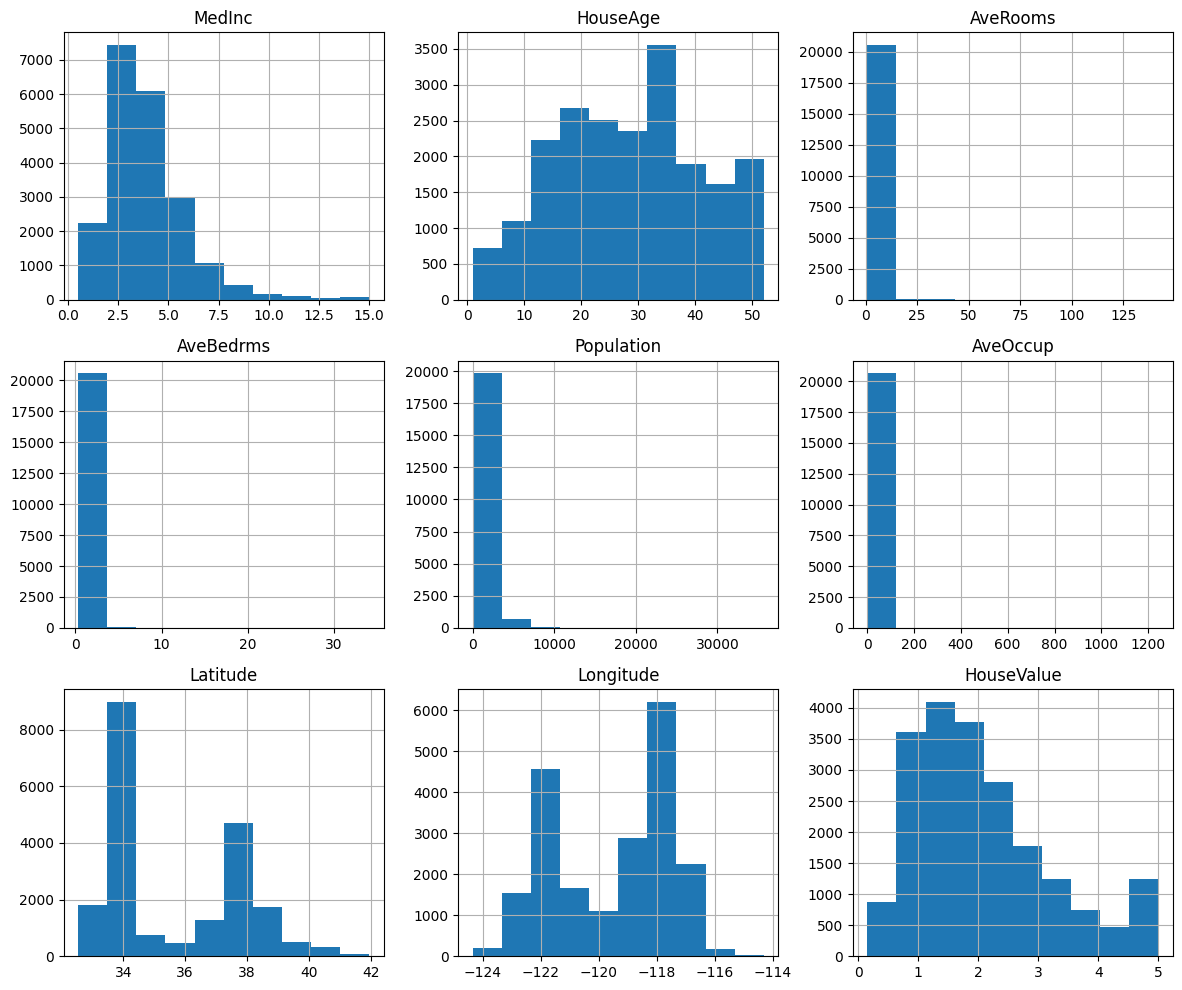

In [ ]:
# Plot histograms for all features
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

### Histogram Observations

- Most numerical features are right-skewed.
- Features such as Population, AveRooms, and AveOccup contain potential outliers.
- The target variable (HouseValue) is concentrated around lower and medium values.
- Latitude and Longitude show multiple peaks because houses are distributed across different geographical regions.

### Import seaborn lib to visually shows how strongly each feature is related to every other feature—especially to HouseValue.

In [ ]:
import seaborn as sns

## 3.3 Correlation Matrix

In [ ]:
correlation = df.corr()

correlation

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
HouseValue,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


### Correlation Analysis

- Median Income (MedInc) has the strongest positive correlation (0.69) with HouseValue.
- Features such as Population and AveOccup have very weak correlations with HouseValue.
- Latitude shows a weak negative correlation with HouseValue.
- Correlation indicates the strength and direction of a relationship but does not imply causation.

### 3.3.1 Correlation Heatmap

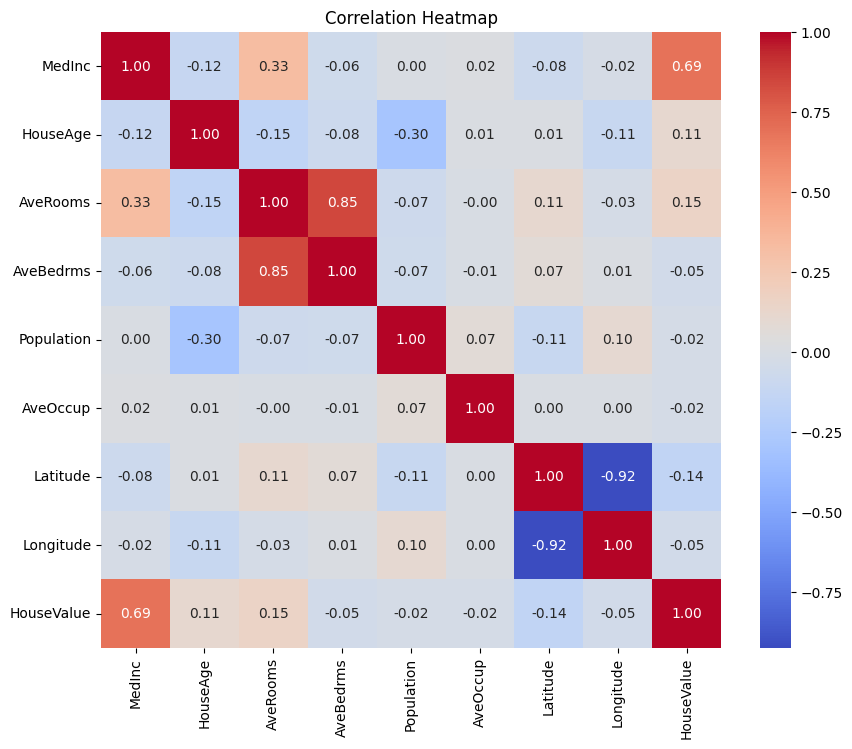

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# 4. Data Preprocessing

## 4.1 Feature Selection

In [ ]:
# Features (input variables)
X = df.drop("HouseValue", axis=1)

# Target (output variable)
y = df["HouseValue"]

In [ ]:
print(X.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [ ]:
print(y.head())

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HouseValue, dtype: float64


# 5. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 6. Model Training

## 6.1 Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# 7. Model Prediction

In [ ]:
# Predict house prices on the test dataset
y_pred = model.predict(X_test)

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657
13311,1.58700,2.011754
7113,1.98200,2.645500
7668,1.57500,2.168755
18246,3.40000,2.740746
5723,4.46600,3.915615


### Observation

The trained Linear Regression model generated predictions for the unseen test dataset. The predicted values are close to the actual house prices, indicating that the model has learned the relationship between the input features and the target variable.

# 8. Model Evaluation

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

In [ ]:
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.5332
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758


### Observation

The Linear Regression model achieved an MAE of 0.5332, an RMSE of 0.7456, and an R² score of 0.5758. These results indicate that the model captures a significant portion of the relationship between the input features and house prices. Although the model is not perfectly accurate, its performance is satisfactory for a baseline Linear Regression model.

# 9. Model Performance Visualization


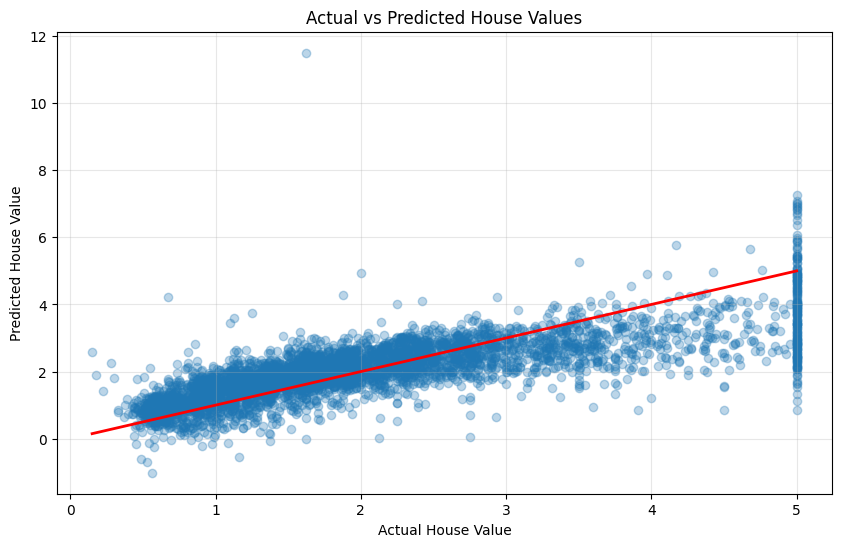

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)
plt.grid(alpha=0.3)



plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

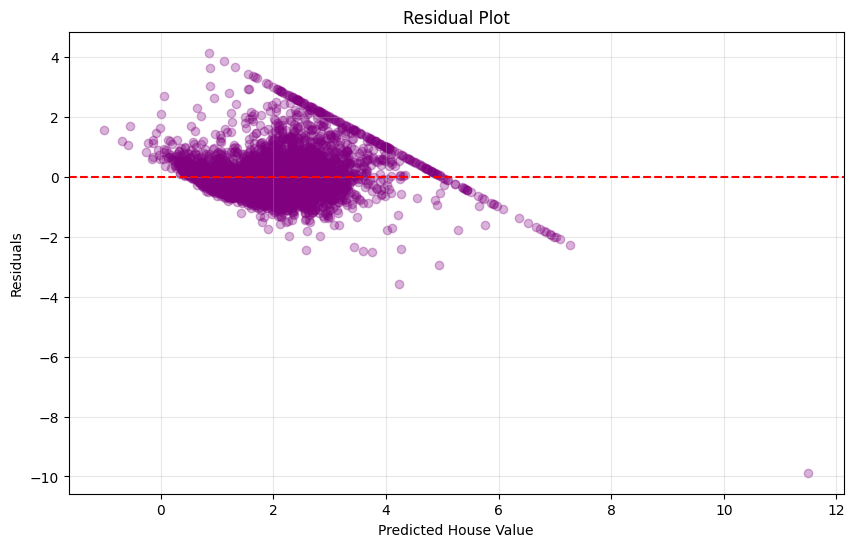

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.3,color="purple")

plt.axhline(y=0, color="red", linestyle="--")

plt.grid(alpha=0.3)

plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# 10. Save the Trained Model

In [ ]:
import pickle

with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
